## imports and settings

In [1]:
import pandas as pd
import numpy as np
import requests
import itertools
import ast

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from nltk.stem import SnowballStemmer
from bs4 import BeautifulSoup

# use this for py file
# repoP = Path(__file__).resolve().parent.parent

# for notebook
repoP = Path.cwd().parent

germanWorksP = repoP / "data/german-works"

## assignment 1

Entwickeln Sie ein eigenes Python-Skript, das die 10 Paare von Werken ermittelt, die die höchste Jaccard-Ähnlichkeit aufweisen. Geben Sie für jedes der zehn Paare die Namen der Werke sowie die zugehörigen Autoren und den berechneten Jaccard-Ähnlichkeitswert aus. Beim Vergleich sollen auch Paare von Werken desselben Autors berücksichtigt werden.

### get everything in a DF first

In [2]:
toDFdict = {
    "author": [],
    "workId": [],
    "work_tokenList": [],
    "work_termList": []
}

# set stemmer
stemmer = SnowballStemmer("german")

# get folders for authors
authorFolderPs = [p for p in germanWorksP.iterdir() if p.is_dir()]

# iterate through them
for authorFolderP in authorFolderPs:

    # get .tokens files and iterate through them
    for tokenFile in authorFolderP.glob("*.tokens"):

        # open every single one
        with open(tokenFile, encoding="utf-8") as tf:

            # get tokes as list
            tokenList = tokenFile.read_text().split("\n")   # read file content as string and split at newline chars

            # create term set from that list (use stemmer because why not)
            termSet = set()
            for token in tokenList:
                token = stemmer.stem(token.strip())
                if token:
                    termSet.add(token)

            # cast to list
            termList = list(termSet)

            # now create row in DF
            toDFdict["author"].append(authorFolderP.name)
            toDFdict["workId"].append(tokenFile.name.replace(".tokens", ""))
            toDFdict["work_tokenList"].append(tokenList)
            toDFdict["work_termList"].append(termList)

# create DF from dict            
dataDF = pd.DataFrame.from_dict(toDFdict)

In [4]:
dataDF

,author,workId,work_tokenList,work_termList
0,Hesse,2499,"[produced, michael, pullen, globaltraveler5565...","[vermind, krieg, beleidigt, sterbenmuss, recht..."
1,Hesse,42338,"[klingsors, letzter, sommer, erzählungen, herm...","[ungebeugt, seiltanz, abgedeckt, auszudruck, k..."
2,Hesse,17622,"[produced, greiner, markus, brenner, online, d...","[krieg, hierbleib, holund, gedankenvoll, sarg,..."
3,Hesse,46135,"[romantische, lieder, hermann, hesse, dresden,...","[krieg, vorbeigegang, dichterwelt, sarg, kostl..."
4,Hesse,41907,"[demian, geschichte, emil, sinclairs, jugend, ...","[krieg, beleidigt, gottgefall, glaubenssatz, e..."
...,...,...,...,...
197,Lessing,9326,"[produced, delphine, lettau, gutenberg, projek...","[verfass, vorneherein, abwes, freimàur, sichr,..."
198,Lessing,9187,"[produced, mike, pullen, delphine, lettau, fro...","[krieg, hierbleib, nachspuckt, hingeritt, wegg..."
199,Lessing,9375,"[produced, delphine, lettau, mike, pullen, thi...","[krieg, beleidigt, kaum, fall, speis, unbescha..."
200,Lessing,6889,"[produced, delphine, lettau, gutenberg, projek...","[pultess, auszudruck, cyklop, ignarus, revocav..."


In [6]:
# quick manual check with file

#assert len(dataDF.iloc[0]["work_tokenList"]) == 20416 # lookup in data/german-works/Fontane/26686.tokens

### fetch and enrich workLabel

https://www.gutenberg.org/ebooks/52912
<br>
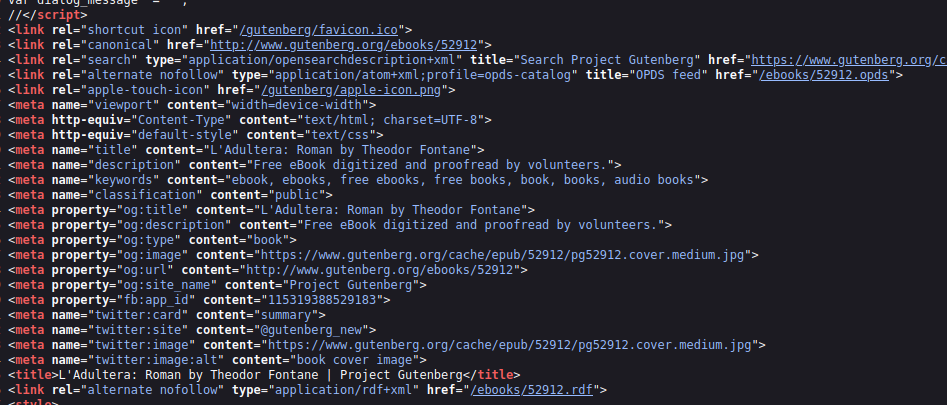

In [40]:
def fetchWorkLabel(workId: str) -> list[str | None, str | None]:

    # create url
    url = f"https://www.gutenberg.org/ebooks/{workId}"

    try:
        print(f"Fetching workLabel for workId {workId}.")

        # get request
        res = session.get(url)
        res.raise_for_status()

        # get and parse html
        labelSoup = BeautifulSoup(res.text, "html.parser")

        # get meta tag
        metaTag = labelSoup.find("meta", attrs={"name": "title"})

        if metaTag:
            titleLabel = metaTag["content"]

            print(f"Resulting label: {titleLabel}")
            return [titleLabel, None]

        else:
            print("FetchError: Error while fetching title from according meta tag.")
            return [None, "FetchError: Error while fetching title from according meta tag."]

    except Exception as e:
        print(f"FetchError: {e}.")
        return [None, f"FetchError: {e}."]

In [41]:
# use single session to reduce overhead
with requests.Session() as session:

    # apply function to column, use .apply(pd.Series) to split list into individual columns
    expandedColsDF = dataDF["workId"].apply(fetchWorkLabel).apply(pd.Series)

    # rename newly generated columns
    expandedColsDF.columns = ["workLabel", "fetchError"]

    # join back to original DataFrame
    dataDF = dataDF.join(expandedColsDF)

Fetching workLabel for workId 26686.
Resulting label: Unterm Birnbaum by Theodor Fontane
Fetching workLabel for workId 36905.
Resulting label: Schach von Wuthenow by Theodor Fontane
Fetching workLabel for workId 46184.
Resulting label: Frau Jenny Treibel: Roman aus der Berliner Gesellschaft by Theodor Fontane
Fetching workLabel for workId 47311.
Resulting label: Wanderungen durch die Mark Brandenburg, Dritter Teil by Theodor Fontane
Fetching workLabel for workId 52912.
Resulting label: L'Adultera: Roman by Theodor Fontane
Fetching workLabel for workId 5323.
Resulting label: Effi Briest by Theodor Fontane
Fetching workLabel for workId 53628.
Resulting label: Der Stechlin: Roman by Theodor Fontane
Fetching workLabel for workId 75277.
Resulting label: Kriegsgefangen :  Erlebtes 1870. by Theodor Fontane
Fetching workLabel for workId 10353.
Resulting label: Satyros oder Der vergötterte Waldteufel by Johann Wolfgang von Goethe
Fetching workLabel for workId 10354.
Resulting label: Die Laune d

In [46]:
# quick check if every work now has a workLabel

dataDF[dataDF["workLabel"].isna()]

,author,workId,work_tokenList,work_termList,workLabel


In [43]:
# check for fetchErrors

dataDF[dataDF["fetchError"].notna()]

,author,workId,work_tokenList,work_termList,workLabel,fetchError


In [44]:
# no errors - get rid of column

dataDF = dataDF.drop(columns=["fetchError"])

In [ ]:
# out of curiosity: the " by " in workLabel seems suspicious.. is it in every workLabel?

dataDF[dataDF["workLabel"].str.contains(" by ")]

,author,workId,work_tokenList,work_termList,workLabel
0,Fontane,26686,"[produced, markus, brenner, online, distribute...","[montmirail, frei, prompt, weinkell, malt, lie...",Unterm Birnbaum by Theodor Fontane
1,Fontane,36905,"[produced, jana, srna, norbert, langkau, onlin...","[frei, bemerkenswerth, versicher, nachgegeb, b...",Schach von Wuthenow by Theodor Fontane
2,Fontane,46184,"[anmerkungen, transkription, rechtschreibung, ...","[frei, malt, instinktiv, versicher, abwag, bes...",Frau Jenny Treibel: Roman aus der Berliner Ges...
3,Fontane,47311,"[anmerkungen, transkription, original, gesperr...","[frei, malt, varnhag, vierhundertjahr, versich...","Wanderungen durch die Mark Brandenburg, Dritte..."
4,Fontane,52912,"[anmerkungen, transkription, original, fraktur...","[frei, beunruhigt, versicher, kanevas, nachgeg...",L'Adultera: Roman by Theodor Fontane
...,...,...,...,...,...
197,Twain,66952,"[anmerkungen, transkription, original, fraktur...","[frei, malt, ehegatt, beunruhigt, schurkerei, ...",Wie Hadleyburg verderbt wurde: Nebst anderen E...
198,Wieland,2187,"[this, etext, prepared, michael, pullen, globa...","[schlafend, nithart, versicher, jugendlicht, b...",Oberon by Christoph Martin Wieland
199,Wieland,2313,"[this, etext, prepared, michael, pullen, alpha...","[frei, ausbrutet, malt, schlafend, beunruhigt,...",Geschichte des Agathon. Teil 1 by Christoph Ma...
200,Wieland,2314,"[this, etext, prepared, michael, pullen, alpha...","[frei, heuchelei, malt, schlafend, versicher, ...",Geschichte des Agathon. Teil 2 by Christoph Ma...


In [49]:
# no not in every one -> these two do not contain " by "

dataDF[~dataDF["workLabel"].str.contains(" by ")]

,author,workId,work_tokenList,work_termList,workLabel
84,Humboldt,22659,"[rede, gehalten, eröffnung, versammlung, deuts...","[frei, bestimmt, bearbeit, durchlauft, schritt...","Rede, gehalten bei der Eröffnung der Versammlu..."
102,Kant,38295,"[produced, norbert, langkau, jana, srna, onlin...","[offensicht, schritt, ausbricht, bestand, auff...","Von der Macht des Gemüts, durch den bloßen Vor..."


In [50]:
# in detail:
print(dataDF.iloc[84]["workLabel"])
print(dataDF.iloc[102]["workLabel"])

Rede, gehalten bei der Eröffnung der Versammlung deutscher Naturforscher und…
Von der Macht des Gemüts, durch den bloßen Vorsatz seiner krankhaften Gefühle…


### base analyses

In [96]:
# duplicates?
dataDF[dataDF["workId"].duplicated(keep=False)]

,author,workId,work_tokenList,work_termList,workLabel,work_termCount,uniqueWorkId
45,Goethe,31216,"[produced, karl, eichwalder, jana, srna, onlin...","[realitat, bewundert, widerruf, bearbeit, abtr...",Briefe Schillers und Goethes an A. W. Schlegel...,2073,312160
152,Schiller,31216,"[produced, karl, eichwalder, jana, srna, onlin...","[realitat, bewundert, widerruf, bearbeit, abtr...",Briefe Schillers und Goethes an A. W. Schlegel...,2073,312161


In [95]:
# this needs some refining -> keep workId and set "uniqueWorkId" - Goethe will get 0 appended, Schiller will get 1 appended

dataDF["uniqueWorkId"] = dataDF["workId"]
dataDF.loc[45, "uniqueWorkId"] = "312160"
dataDF.loc[152, "uniqueWorkId"] = "312161"

In [52]:
# authors with the most books

dataDF["author"].value_counts()

author
Goethe      49
Hesse       20
Lessing     18
Storm       18
Schiller    15
Twain       13
Kant        12
Kafka       11
Mann        11
Rilke       11
Fontane      8
Heine        6
Humboldt     6
Wieland      4
Name: count, dtype: int64

In [ ]:
# works with the most terms by author count desc

dataDF["work_termCount"] = dataDF["work_termList"].apply(lambda x: len(x))
dataDF.sort_values(by=["author", "work_termCount"], ascending=[True, False])

,author,workId,work_tokenList,work_termList,workLabel,work_termCount
3,Fontane,47311,"[anmerkungen, transkription, original, gesperr...","[frei, malt, varnhag, vierhundertjahr, versich...","Wanderungen durch die Mark Brandenburg, Dritte...",15458
6,Fontane,53628,"[anmerkungen, transkription, original, fraktur...","[frei, heuchelei, malt, naturwuchs, beunruhigt...",Der Stechlin: Roman by Theodor Fontane,10743
5,Fontane,5323,"[produced, this, ebook, prepared, gunther, ole...","[frei, abtrocknet, dusig, strandsand, beunruhi...",Effi Briest by Theodor Fontane,8062
7,Fontane,75277,"[anmerkungen, transkription, original, fraktur...","[frei, kaleidoskop, schlafend, tupft, beunruhi...",Kriegsgefangen : Erlebtes 1870. by Theodor Fo...,7564
2,Fontane,46184,"[anmerkungen, transkription, rechtschreibung, ...","[frei, malt, instinktiv, versicher, abwag, bes...",Frau Jenny Treibel: Roman aus der Berliner Ges...,6866
...,...,...,...,...,...,...
192,Twain,65346,"[anmerkungen, transkription, original, fraktur...","[frei, malt, bestand, ortszeit, binn, ausfrag,...",Tom Sawyers Neue Abenteuer by Mark Twain,5637
198,Wieland,2187,"[this, etext, prepared, michael, pullen, globa...","[schlafend, nithart, versicher, jugendlicht, b...",Oberon by Christoph Martin Wieland,7103
199,Wieland,2313,"[this, etext, prepared, michael, pullen, alpha...","[frei, ausbrutet, malt, schlafend, beunruhigt,...",Geschichte des Agathon. Teil 1 by Christoph Ma...,6371
200,Wieland,2314,"[this, etext, prepared, michael, pullen, alpha...","[frei, heuchelei, malt, schlafend, versicher, ...",Geschichte des Agathon. Teil 2 by Christoph Ma...,5998


### export and import dataDF

#### export

In [97]:
dataDF.to_csv(repoP / "docs/assignment/baseData.csv", index=False)

#### import

In [7]:
dataDF = pd.read_csv(repoP / "docs/assignment/baseData.csv", dtype=str)

dataDF["work_termCount"] = dataDF["work_termCount"].astype(int)

# bring back native py data types
dataDF["work_tokenList"] = dataDF["work_tokenList"].apply(lambda x: ast.literal_eval(x))
dataDF["work_termList"] = dataDF["work_termList"].apply(lambda x: ast.literal_eval(x))

In [8]:
# quick check

type(dataDF.iloc[0]["work_termList"])

list

In [12]:
dataDF.sample()

,author,workId,work_tokenList,work_termList,workLabel,work_termCount,uniqueWorkId
50,Goethe,49024,"[anmerkungen, transkription, schreibweise, int...","[tactiqu, katharina, realitat, liebt, freut, s...",Goethes Briefe an Auguste zu Stolberg by Goeth...,2630,49024


### calculate jaccard similarity for all work combinations

In [13]:
# use itertools.combinations to create unique pairs of workIds (order does not matter, no self-pairs)
pairs = list(itertools.combinations(list(dataDF["uniqueWorkId"]), 2))

In [17]:
# create DF from that
jaccardDF = pd.DataFrame(pairs, columns=["work_A", "work_B"])

In [18]:
jaccardDF

,work_A,work_B
0,26686,36905
1,26686,46184
2,26686,47311
3,26686,52912
4,26686,5323
...,...,...
20296,2187,2314
20297,2187,46580
20298,2313,2314
20299,2313,46580


In [19]:
# re-use from script `06_compute-author-similarity.py`

def compute_similarity(terms_A, terms_B, mode="jaccard"):
    """
    Berechnet die Ähnlichkeit zwischen zwei Autoren basierend auf den zugehörigen Term-Mengen ihrer Werke.

    Parameter:
    - terms_A: Menge der Terme aus den Werken des ersten Autors
    - terms_B: Menge der Terme aus den Werken des zweiten Autors
    - mode: Modus der Ähnlichkeitsberechnung ("jaccard", "dice", "otsuka-ochiai")
    """
    intersection = terms_A & terms_B # Schnittmenge der Term-Mengen beider Autoren
    if mode == "jaccard":
        union = terms_A | terms_B # Vereinigungsmenge der Term-Mengen beider Autoren
        similarity = len(intersection) / len(union) if union else 0
    elif mode == "dice":
        # bietet sich an, wenn die beiden Term-Mengen sehr unterschiedlich groß sind (Normierung der Größe der
        # Schnittmenge durch das arithmetische Mittel der Größen der beiden Term-Mengen)
        len_arithmetic_mean = 0.5 * (len(terms_A) + len(terms_B))
        similarity = len(intersection) / len_arithmetic_mean if len_arithmetic_mean > 0 else 0
    elif mode == "otsuka-ochiai":
        # bietet sich an, wenn die beiden Term-Mengen sehr unterschiedlich groß sind (Normierung der Größe der
        # Schnittmenge durch das geometrische Mittel der Größen der beiden Term-Mengen)
        len_geom_mean = (len(terms_A) * len(terms_B)) ** 0.5
        similarity = len(intersection) / len_geom_mean if len_geom_mean > 0 else 0
    else:
        similarity = 0

    # return similarity:.4f
    return similarity


# little wrapper
def wrapCompSim(workId_A: str, workId_B: str) -> float:

    # get terms from dataDF via uniqueWorkId
    terms_A = set(dataDF[dataDF["uniqueWorkId"] == workId_A].iloc[0]["work_termList"])
    terms_B = set(dataDF[dataDF["uniqueWorkId"] == workId_B].iloc[0]["work_termList"])

    # call base function
    similarity = compute_similarity(terms_A, terms_B)

    return similarity

In [20]:
# apply function to jaccardDF

jaccardDF["jaccardSimilarity"] = jaccardDF.apply(lambda row: wrapCompSim(row["work_A"], row["work_B"]), axis=1)

In [21]:
jaccardDF

,work_A,work_B,jaccardSimilarity
0,26686,36905,0.235789
1,26686,46184,0.221319
2,26686,47311,0.153085
3,26686,52912,0.225814
4,26686,5323,0.219135
...,...,...,...
20296,2187,2314,0.220969
20297,2187,46580,0.204364
20298,2313,2314,0.415541
20299,2313,46580,0.258627


### export and import jaccardDF

#### export

In [8]:
jaccardDF.to_csv(repoP / "docs/assignment/jaccardSimilarityData.csv", index=False)

#### import

In [19]:
jaccardDF = pd.read_csv(repoP / "docs/assignment/jaccardSimilarityData.csv", dtype=str)

jaccardDF["jaccardSimilarity"] = jaccardDF["jaccardSimilarity"].astype(float)

In [20]:
type(jaccardDF.iloc[0]["jaccardSimilarity"])

numpy.float64

In [21]:
jaccardDF

,work_A,work_B,jaccardSimilarity
0,26686,36905,0.235789
1,26686,46184,0.221319
2,26686,47311,0.153085
3,26686,52912,0.225814
4,26686,5323,0.219135
...,...,...,...
20296,2187,2314,0.220969
20297,2187,46580,0.204364
20298,2313,2314,0.415541
20299,2313,46580,0.258627


### print top10 (assignment solution)

In [22]:
# now to the assignment: top 10 pairs with the highest jaccardSimilarity, also workLabel and authors

# order DF first:
jaccardDF = jaccardDF.sort_values(by="jaccardSimilarity", ascending=False)
jaccardDF = jaccardDF.reset_index(drop=True)

In [24]:
jaccardDF

,work_A,work_B,jaccardSimilarity
0,312160,312161,1.000000
1,5325,7875,0.960362
2,6342,6343,0.867797
3,21000,2229,0.753549
4,30165,64417,0.424619
...,...,...,...
20296,38638,30570,0.006723
20297,22492,30570,0.006473
20298,47311,39792,0.006316
20299,30570,10055,0.006234


In [25]:
# order DF first:
top10DF = jaccardDF.head(10)

print("===================================================================")
print("TOP 10 SIMILAR WORKS")
print("===================================================================\n\n")

for idx, row in top10DF.iterrows():

    print("===================================================================")
    print(f"TOP {idx + 1} - SIMILARITY SCORE: {row["jaccardSimilarity"]}")
    print("-------------------------------------------------------------------")
    print("WORK A")
    print(f"Unique WorkId: {row["work_A"]}")
    print(f"Original WorkId: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["workId"]}")
    print(f"Work Label: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["workLabel"]}")
    print(f"Author: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["author"]}")
    print("-------------------------------------------------------------------")
    print("WORK B")
    print(f"Unique WorkId: {row["work_B"]}")
    print(f"Original WorkId: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["workId"]}")
    print(f"Work Label: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["workLabel"]}")
    print(f"Author: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["author"]}")
    print("===================================================================\n")
    


TOP 10 SIMILAR WORKS


TOP 1 - SIMILARITY SCORE: 1.0
-------------------------------------------------------------------
WORK A
Unique WorkId: 312160
Original WorkId: 31216
Work Label: Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe
Author: Goethe
-------------------------------------------------------------------
WORK B
Unique WorkId: 312161
Original WorkId: 31216
Work Label: Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe
Author: Schiller

TOP 2 - SIMILARITY SCORE: 0.9603616133518776
-------------------------------------------------------------------
WORK A
Unique WorkId: 5325
Original WorkId: 5325
Work Label: Römische Elegien by Johann Wolfgang von Goethe
Author: Goethe
-------------------------------------------------------------------
WORK B
Unique WorkId: 7875
Original WorkId: 7875
Work Label: Römische Elegien by Johann Wolfgang von Goethe
Author: Goethe

TOP 3 - SIMILARITY SCORE: 0.8677971424085413
-------------------------------------

## assignment 2

Bestimmen Sie anschließend für die Werke, die in den zehn Paaren mit der höchsten Jaccard-Ähnlichkeit vorkommen, eine Heatmap der Jaccard-Ähnlichkeitswerte zwischen diesen Werken (die Heatmap kann somit höchstens 20 Zeilen und 20 Spalten umfassen). Vergleichen Sie die berechnete Heatmap mit der zuvor berechneten Heatmap der Jaccard-Ähnlichkeitswerte zwischen den Autoren (bzw. ihren Term-Mengen).

### load jaccardDF and order values

In [26]:
jaccardDF = pd.read_csv(repoP / "docs/assignment/jaccardSimilarityData.csv", dtype=str)

jaccardDF["jaccardSimilarity"] = jaccardDF["jaccardSimilarity"].astype(float)

In [27]:
labeledJaccardDF = jaccardDF.sort_values(by="jaccardSimilarity", ascending=False)
labeledJaccardDF = labeledJaccardDF.reset_index(drop=True)

In [28]:
labeledJaccardDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 20301 entries, 0 to 20300
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   work_A             20301 non-null  str    
 1   work_B             20301 non-null  str    
 2   jaccardSimilarity  20301 non-null  float64
dtypes: float64(1), str(2)
memory usage: 475.9 KB


In [29]:
labeledJaccardDF.describe()

,jaccardSimilarity
count,20301.000000
mean,0.161749
std,0.059719
min,0.005166
25%,0.123280
50%,0.167434
75%,0.201617
max,1.000000


In [30]:
labeledJaccardDF.sample()

,work_A,work_B,jaccardSimilarity
26,9157,9325,0.336347


In [31]:
labeledJaccardDF.head()

,work_A,work_B,jaccardSimilarity
0,312160,312161,1.000000
1,5325,7875,0.960362
2,6342,6343,0.867797
3,21000,2229,0.753549
4,30165,64417,0.424619


### enrich jaccardDF with author_workLabel

In [114]:
dataDF.sample()

,author,workId,work_tokenList,work_termList,workLabel,work_termCount,uniqueWorkId
185,Twain,30165,"[transcriber's, note, this, book, transcribed,...","[frei, errungenschaft, malt, schlafend, beunru...",Die Abenteuer Tom Sawyers by Mark Twain,6710,30165


In [115]:
labeledJaccardDF.sample()

,work_A,work_B,jaccardSimilarity
15874,56182,6822,0.115636


In [116]:
def enrichWorkIds(row: pd.Series) -> list[str, str]:

    authorA = dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["author"]
    workLabelA = dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["workLabel"]

    workA_authorWorkLabel = f"{row["work_A"]}_{authorA}_{workLabelA}"

    authorB = dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["author"]
    workLabelB = dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["workLabel"]

    workB_authorWorkLabel = f"{row["work_B"]}_{authorB}_{workLabelB}"

    return pd.Series([workA_authorWorkLabel, workB_authorWorkLabel], index=["workA_authorWorkLabel", "workB_authorWorkLabel"])

newCols = ["workA_authorWorkLabel", "workB_authorWorkLabel"]
labeledJaccardDF[newCols] = labeledJaccardDF.apply(enrichWorkIds, axis=1)

In [118]:
labeledJaccardDF

,work_A,work_B,jaccardSimilarity,workA_authorWorkLabel,workB_authorWorkLabel
0,312160,312161,1.000000,312160_Goethe_Briefe Schillers und Goethes an ...,312161_Schiller_Briefe Schillers und Goethes a...
1,5325,7875,0.960362,5325_Goethe_Römische Elegien by Johann Wolfgan...,7875_Goethe_Römische Elegien by Johann Wolfgan...
2,6342,6343,0.867797,6342_Kant_Kritik der reinen Vernunft by Immanu...,6343_Kant_Kritik der reinen Vernunft by Immanu...
3,21000,2229,0.753549,21000_Goethe_Faust: Eine Tragödie [erster Teil...,2229_Goethe_Faust: Der Tragödie erster Teil by...
4,30165,64417,0.424619,30165_Twain_Die Abenteuer Tom Sawyers by Mark ...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
...,...,...,...,...,...
20296,38638,30570,0.006723,38638_Humboldt_Reise in die Aequinoctial-Gegen...,30570_Kafka_Grosser Lärm by Franz Kafka
20297,22492,30570,0.006473,22492_Humboldt_Reise in die Aequinoctial-Gegen...,30570_Kafka_Grosser Lärm by Franz Kafka
20298,47311,39792,0.006316,47311_Fontane_Wanderungen durch die Mark Brand...,39792_Heine_Das Lied vom blöden Ritter by Hein...
20299,30570,10055,0.006234,30570_Kafka_Grosser Lärm by Franz Kafka,10055_Lessing_Hamburgische Dramaturgie by Gott...


### export and import

#### export

In [119]:
labeledJaccardDF.to_csv(repoP / "docs/assignment/labeledJaccardSimilarityData.csv", index=False)

#### import

In [32]:
labeledJaccardDF = pd.read_csv(repoP / "docs/assignment/labeledJaccardSimilarityData.csv", dtype=str)

labeledJaccardDF["jaccardSimilarity"] = labeledJaccardDF["jaccardSimilarity"].astype(float)

In [33]:
labeledJaccardDF.iloc[1]["jaccardSimilarity"]

np.float64(0.9603616133518776)

### get all unique workIds that are present in the top 10

In [34]:
top10DF = labeledJaccardDF.head(10)

In [35]:
top10DF

,work_A,work_B,jaccardSimilarity,workA_authorWorkLabel,workB_authorWorkLabel
0,312160,312161,1.000000,312160_Goethe_Briefe Schillers und Goethes an ...,312161_Schiller_Briefe Schillers und Goethes a...
1,5325,7875,0.960362,5325_Goethe_Römische Elegien by Johann Wolfgan...,7875_Goethe_Römische Elegien by Johann Wolfgan...
2,6342,6343,0.867797,6342_Kant_Kritik der reinen Vernunft by Immanu...,6343_Kant_Kritik der reinen Vernunft by Immanu...
3,21000,2229,0.753549,21000_Goethe_Faust: Eine Tragödie [erster Teil...,2229_Goethe_Faust: Der Tragödie erster Teil by...
4,30165,64417,0.424619,30165_Twain_Die Abenteuer Tom Sawyers by Mark ...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
5,2313,2314,0.415541,2313_Wieland_Geschichte des Agathon. Teil 1 by...,2314_Wieland_Geschichte des Agathon. Teil 2 by...
6,2341,2342,0.369643,2341_Goethe_Wilhelm Meisters Lehrjahre — Band ...,2342_Goethe_Wilhelm Meisters Lehrjahre — Band ...
7,10425,10426,0.361845,10425_Goethe_Torquato Tasso by Johann Wolfgang...,10426_Goethe_Die natürliche Tochter by Johann ...
8,2403,2411,0.354083,2403_Goethe_Die Wahlverwandtschaften by Johann...,2411_Goethe_Wilhelm Meisters Wanderjahre — Ban...
9,2410,2411,0.352979,2410_Goethe_Wilhelm Meisters Wanderjahre — Ban...,2411_Goethe_Wilhelm Meisters Wanderjahre — Ban...


In [36]:
workIdsForHeatMap = list(set(top10DF["work_A"]) | set(top10DF["work_B"]))

In [37]:
len(workIdsForHeatMap)

19

In [38]:
# filter the jaccardDF for rows where both works are in worksForHeatMap
heatMapDF = labeledJaccardDF[
    labeledJaccardDF["work_A"].isin(workIdsForHeatMap) & 
    labeledJaccardDF["work_B"].isin(workIdsForHeatMap)
]

In [39]:
heatMapDF

,work_A,work_B,jaccardSimilarity,workA_authorWorkLabel,workB_authorWorkLabel
0,312160,312161,1.000000,312160_Goethe_Briefe Schillers und Goethes an ...,312161_Schiller_Briefe Schillers und Goethes a...
1,5325,7875,0.960362,5325_Goethe_Römische Elegien by Johann Wolfgan...,7875_Goethe_Römische Elegien by Johann Wolfgan...
2,6342,6343,0.867797,6342_Kant_Kritik der reinen Vernunft by Immanu...,6343_Kant_Kritik der reinen Vernunft by Immanu...
3,21000,2229,0.753549,21000_Goethe_Faust: Eine Tragödie [erster Teil...,2229_Goethe_Faust: Der Tragödie erster Teil by...
4,30165,64417,0.424619,30165_Twain_Die Abenteuer Tom Sawyers by Mark ...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
...,...,...,...,...,...
16480,5325,64417,0.108715,5325_Goethe_Römische Elegien by Johann Wolfgan...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
17423,5325,6342,0.095772,5325_Goethe_Römische Elegien by Johann Wolfgan...,6342_Kant_Kritik der reinen Vernunft by Immanu...
17429,7875,6342,0.095733,7875_Goethe_Römische Elegien by Johann Wolfgan...,6342_Kant_Kritik der reinen Vernunft by Immanu...
17628,5325,6343,0.092737,5325_Goethe_Römische Elegien by Johann Wolfgan...,6343_Kant_Kritik der reinen Vernunft by Immanu...


### build matrix and draw heatmap (assignment solution)

In [40]:
# re-use code

def build_matrix(df: pd.DataFrame) -> pd.DataFrame:
    df = df[["workA_authorWorkLabel", "workB_authorWorkLabel", "jaccardSimilarity"]].copy()

    matrix = df.pivot_table(
        index="workA_authorWorkLabel",
        columns="workB_authorWorkLabel",
        values="jaccardSimilarity",
        aggfunc="mean",
    )

    matrix = matrix.combine_first(matrix.T)
    all_ids = sorted(set(matrix.index) | set(matrix.columns))
    matrix = matrix.reindex(index=all_ids, columns=all_ids)
    for i in range(len(matrix)):
        matrix.iat[i, i] = 1.0
    return matrix.fillna(0.0)


def draw_heatmap(matrix: pd.DataFrame, output: str) -> None:
    n = len(matrix)
    cell = max(0.55, min(1.1, 11 / max(1, n)))
    plt.figure(figsize=(n * cell + 2.5, n * cell + 1.8))

    sns.heatmap(
        matrix,
        cmap="OrRd",
        vmin=0.0,
        vmax=1.0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"label": "Ähnlichkeit", "shrink": 0.8},
    )

    plt.title(f"Jaccard-Ähnlichkeitsmatrix der Werke", fontsize=12, pad=12)
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(output, dpi=300, bbox_inches="tight")
    plt.close()

In [41]:
heatMapDF

,work_A,work_B,jaccardSimilarity,workA_authorWorkLabel,workB_authorWorkLabel
0,312160,312161,1.000000,312160_Goethe_Briefe Schillers und Goethes an ...,312161_Schiller_Briefe Schillers und Goethes a...
1,5325,7875,0.960362,5325_Goethe_Römische Elegien by Johann Wolfgan...,7875_Goethe_Römische Elegien by Johann Wolfgan...
2,6342,6343,0.867797,6342_Kant_Kritik der reinen Vernunft by Immanu...,6343_Kant_Kritik der reinen Vernunft by Immanu...
3,21000,2229,0.753549,21000_Goethe_Faust: Eine Tragödie [erster Teil...,2229_Goethe_Faust: Der Tragödie erster Teil by...
4,30165,64417,0.424619,30165_Twain_Die Abenteuer Tom Sawyers by Mark ...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
...,...,...,...,...,...
16480,5325,64417,0.108715,5325_Goethe_Römische Elegien by Johann Wolfgan...,64417_Twain_Tom Sawyers Abenteuer und Streiche...
17423,5325,6342,0.095772,5325_Goethe_Römische Elegien by Johann Wolfgan...,6342_Kant_Kritik der reinen Vernunft by Immanu...
17429,7875,6342,0.095733,7875_Goethe_Römische Elegien by Johann Wolfgan...,6342_Kant_Kritik der reinen Vernunft by Immanu...
17628,5325,6343,0.092737,5325_Goethe_Römische Elegien by Johann Wolfgan...,6343_Kant_Kritik der reinen Vernunft by Immanu...


In [42]:
matrix = build_matrix(heatMapDF)

In [43]:
matrix

,10425_Goethe_Torquato Tasso by Johann Wolfgang von Goethe,10426_Goethe_Die natürliche Tochter by Johann Wolfgang von Goethe,21000_Goethe_Faust: Eine Tragödie [erster Teil] by Johann Wolfgang von Goethe,2229_Goethe_Faust: Der Tragödie erster Teil by Johann Wolfgang von Goethe,2313_Wieland_Geschichte des Agathon. Teil 1 by Christoph Martin Wieland,2314_Wieland_Geschichte des Agathon. Teil 2 by Christoph Martin Wieland,2341_Goethe_Wilhelm Meisters Lehrjahre — Band 7 by Johann Wolfgang von Goethe,2342_Goethe_Wilhelm Meisters Lehrjahre — Band 8 by Johann Wolfgang von Goethe,2403_Goethe_Die Wahlverwandtschaften by Johann Wolfgang von Goethe,2410_Goethe_Wilhelm Meisters Wanderjahre — Band 2 by Johann Wolfgang von Goethe,2411_Goethe_Wilhelm Meisters Wanderjahre — Band 3 by Johann Wolfgang von Goethe,30165_Twain_Die Abenteuer Tom Sawyers by Mark Twain,312160_Goethe_Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe,312161_Schiller_Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe,5325_Goethe_Römische Elegien by Johann Wolfgang von Goethe,6342_Kant_Kritik der reinen Vernunft by Immanuel Kant,6343_Kant_Kritik der reinen Vernunft by Immanuel Kant,64417_Twain_Tom Sawyers Abenteuer und Streiche by Mark Twain,7875_Goethe_Römische Elegien by Johann Wolfgang von Goethe
workA_authorWorkLabel,,,,,,,,,,,,,,,,,,,
10425_Goethe_Torquato Tasso by Johann Wolfgang von Goethe,1.000000,0.361845,0.253032,0.264003,0.236205,0.230316,0.292204,0.294989,0.237647,0.249756,0.235240,0.197551,0.182927,0.182927,0.223562,0.185709,0.181854,0.201859,0.230490
10426_Goethe_Die natürliche Tochter by Johann Wolfgang von Goethe,0.361845,1.000000,0.236541,0.251504,0.224596,0.218256,0.270493,0.282902,0.244255,0.254418,0.238341,0.203408,0.167894,0.167894,0.201582,0.177424,0.176161,0.206916,0.207634
21000_Goethe_Faust: Eine Tragödie [erster Teil] by Johann Wolfgang von Goethe,0.253032,0.236541,1.000000,0.753549,0.198568,0.189722,0.215229,0.227127,0.206975,0.208163,0.209780,0.200823,0.140828,0.140828,0.153451,0.145799,0.143420,0.213937,0.153468
2229_Goethe_Faust: Der Tragödie erster Teil by Johann Wolfgang von Goethe,0.264003,0.251504,0.753549,1.000000,0.212524,0.203752,0.234477,0.244670,0.225024,0.226218,0.225942,0.211689,0.131070,0.131070,0.161842,0.157106,0.154305,0.220327,0.161807
2313_Wieland_Geschichte des Agathon. Teil 1 by Christoph Martin Wieland,0.236205,0.224596,0.198568,0.212524,1.000000,0.415541,0.258231,0.286012,0.298497,0.282792,0.277453,0.234872,0.153079,0.153079,0.124439,0.249974,0.247190,0.241432,0.125234
2314_Wieland_Geschichte des Agathon. Teil 2 by Christoph Martin Wieland,0.230316,0.218256,0.189722,0.203752,0.415541,1.000000,0.259540,0.285188,0.288060,0.277079,0.275760,0.227589,0.164310,0.164310,0.120394,0.262181,0.260747,0.232539,0.121244
2341_Goethe_Wilhelm Meisters Lehrjahre — Band 7 by Johann Wolfgang von Goethe,0.292204,0.270493,0.215229,0.234477,0.258231,0.259540,1.000000,0.369643,0.285137,0.289165,0.279258,0.225289,0.210111,0.210111,0.178794,0.215832,0.214173,0.215827,0.178912
2342_Goethe_Wilhelm Meisters Lehrjahre — Band 8 by Johann Wolfgang von Goethe,0.294989,0.282902,0.227127,0.244670,0.286012,0.285188,0.369643,1.000000,0.322837,0.320812,0.319374,0.240683,0.197560,0.197560,0.163740,0.236332,0.234637,0.241527,0.163934
2403_Goethe_Die Wahlverwandtschaften by Johann Wolfgang von Goethe,0.237647,0.244255,0.206975,0.225024,0.298497,0.288060,0.285137,0.322837,1.000000,0.347286,0.354083,0.257255,0.155194,0.155194,0.122016,0.246294,0.246925,0.269779,0.122013


In [44]:
draw_heatmap(matrix, repoP / "docs/assignment/works-similarity_jaccard.png")